## Разведывательный анализ данных

1. Скачайте этот ноутбук к себе.
2. Заполните пропущенные ячейки, отвечая на заданные вопросы. Там должен быть код! (если не сказано обратное)
3. Сохраните результат и выложите го на проверку.

#### Полезная литература

- http://pandas.pydata.org/pandas-docs/stable/10min.html
- https://pandas.pydata.org/pandas-docs/stable/indexing.html
- https://pandas.pydata.org/pandas-docs/stable/missing_data.html

В этом задании мы с вами рассмотрим датасет [Adult Data Set](https://archive.ics.uci.edu/ml/datasets/Adult).
Основывается он на данных переписи населения 1994 года в США.

Расшифровка содержимого колонок:

- age: continuous. 
- workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked. 
- fnlwgt: continuous. sampling weight, more here: SIPP Weighting.
- education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool. 
- education-num: continuous. 
- marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse. 
- occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces. 
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried. 
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black. 
- sex: Female, Male. 
- capital-gain: continuous. Income from investment sources, apart from wages/salary.
- capital-loss: continuous. Losses from investment sources, apart from wages/salary.
- hours-per-week: continuous. 
- native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

In [297]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
pd.__version__

'2.2.3'

Если вы увидели warning, не переживайте, всё хорошо. 
- https://stackoverflow.com/questions/40845304/runtimewarning-numpy-dtype-size-changed-may-indicate-binary-incompatibility
- https://github.com/numpy/numpy/pull/432

In [298]:
columns='age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income'.split(',')
# df = pd.read_csv('../../data/adult.csv.gz', na_values='?') # можно загрузить из файла или URL
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', na_values='?', names=columns)
df.head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


1) Выведите последние 10 элеметнов датасета

In [299]:
df.tail(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32551,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32552,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32553,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32554,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32555,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


2) Сколько колонок и сколько строк в этом датасете?

In [300]:
print("Количество строк:", df.shape[0])
print("Количество колонок:", df.shape[1])

Количество строк: 32561
Количество колонок: 15


3) Какие типы данных у элементов этого датасета?

In [301]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

4) Какие признаки имеют пропуски?

In [302]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace(' ?', np.nan)

print(df.isna().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


5 а) Как вы думаете, с чем связаны пропуски этих значение. Напишите развернутый ответ в ячейке ниже.Заполните пропуски наиболее оптимальным способом (выбор способа заполнения ячеек обоснуйте. При необходимости используйте Лекционный материал).

Пропуски могут быть по причине нежелания человека, участвующего в переписи, указывать некоторые данные.  Пропуски будут заполняться строчкой " Unknown", чтобы показать, что это значения неизвестны.

In [303]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(" Unknown")

5 б) По всем признакам имеющихся объектов определить наличие выбросов, обработать аномальные значения (При необходимости используйте Лекционный материал).

In [304]:
nums = df.select_dtypes(include=["int64", "float64"])

for col in nums.columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        print("Для", col, "найдено выбросов:", 0)
        continue

    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    outline = df[(df[col] < low) | (df[col] > high)]
    print("Для", col, "найдено выбросов:", outline.shape[0])
    df[col] = df[col].clip(lower=low, upper=high)

Для age найдено выбросов: 143
Для fnlwgt найдено выбросов: 992
Для education.num найдено выбросов: 1198
Для capital.gain найдено выбросов: 0
Для capital.loss найдено выбросов: 0
Для hours.per.week найдено выбросов: 9008


Аномалии обработаны следующим образом: значения, вышедшие за границы [q1 - 1.5 * iqr, q3 + 1.5 * iqr], обрезаются, то есть им присваиваются значение соответствующей границы.

7) Какой средний возраст женщин и мужчин?

In [305]:
df.groupby('sex')['age'].mean()

sex
Female    36.832977
Male      39.407113
Name: age, dtype: float64

8) Постройте гистограмму(bar) распределения образования людей (education)

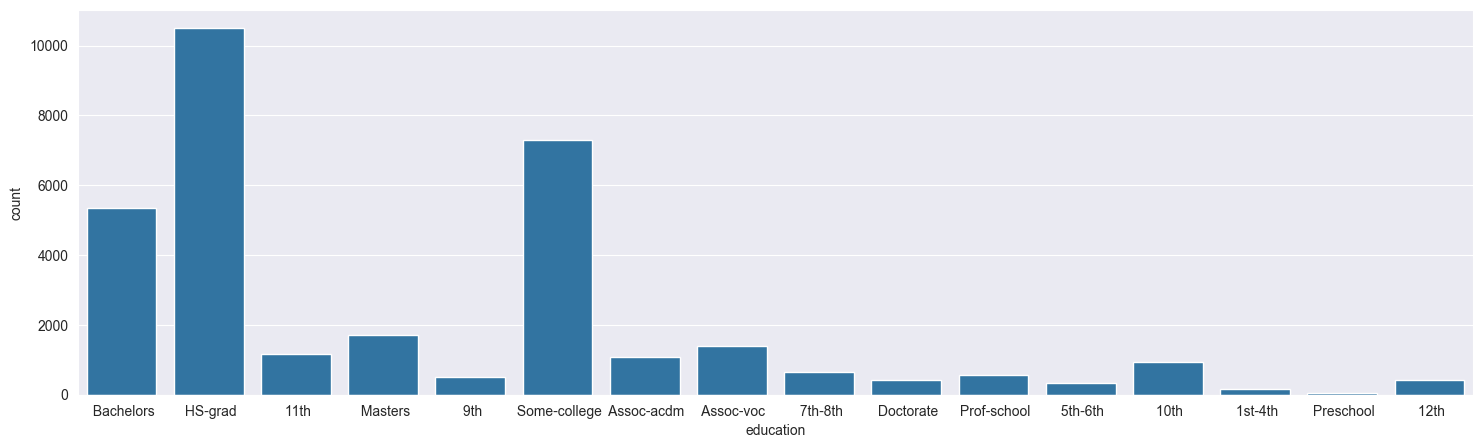

In [306]:
plt.figure(figsize=(18, 5))
sns.countplot(x="education", data=df)
plt.show()

9) Каковы средние значения и среднеквадратичные отклонения возраста тех, кто получает более 50K в год (признак salary) и тех, кто получает менее 50K в год?

In [307]:
rich_age =  df[df['income'] == " >50K"]['age']
poor_age = df[df['income'] == " <=50K"]['age']

print("Rich Age Mean:", rich_age.mean())
print("Poor Age Mean:", poor_age.mean())

print("Rich Age Std:", rich_age.std())
print("Poor Age Std:", poor_age.std())

Rich Age Mean: 44.23275092462696
Poor Age Mean: 36.75485436893204
Rich Age Std: 10.456214766354119
Poor Age Std: 13.925455050831866


10) Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? (признак education - Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters или Doctorate)

In [308]:
high_edu = [' Bachelors', ' Prof-school', ' Assoc-acdm', ' Assoc-voc', ' Masters', ' Doctorate']

res = True

rich_edu = df[df['income'] == " >50K"]['education']
for edu in rich_edu:
    if edu not in high_edu:
        print(edu)
        res = False
        break
print("Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование?", res)

 HS-grad
Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? False


11) Среди кого больше доля зарабатывающих много (>50K): среди женатых или холостых мужчин (признак marital-status)? Женатыми считаем тех, у кого marital-status начинается с Married (Married-civ-spouse, Married-spouse-absent или Married-AF-spouse), остальных считаем холостыми.

In [309]:
married = [' Married-civ-spouse', ' Married-spouse-absent', ' Married-AF-spouse']

rich_married_count = df[(df['income'] == " >50K") & (df["marital.status"].isin(married))].shape[0]
rich_unmarried_count = df[(df['income'] == " >50K") & (~df["marital.status"].isin(married))].shape[0]

print("Rich Married Count:", rich_married_count)
print("Rich Unmarried Count:", rich_unmarried_count)

Rich Married Count: 6736
Rich Unmarried Count: 1105


12) Посчитайте среднее время работы (hours-per-week) зарабатывающих мало и много (salary) для каждой страны (native-country).

In [310]:
df.groupby(["native.country", "income"])["hours.per.week"].agg("mean")

native.country  income
Cambodia        <=50K     41.416667
                >50K      40.000000
Canada          <=50K     39.804878
                >50K      44.358974
China           <=50K     39.700000
                            ...    
Unknown         >50K      44.003425
Vietnam         <=50K     39.314516
                >50K      39.200000
Yugoslavia      <=50K     41.500000
                >50K      46.166667
Name: hours.per.week, Length: 82, dtype: float64

13) Постройте сводную таблицу для сравнения уровня образования и разницы между capital.gain и capital.loss (то есть пассивный доход). Сделайте так, чтобы capital.gain - capital.loss создали не больше 10 разных уникальных значений. То есть, gain и loss - это числа в каком-то диапазоне. Это количественные признаки из вещественных чисел. С помощью математических функций, типа log, извлечение корня N-ой степени и округления можно перейти к категориальным признакам.

In [311]:
df["passive_income"] = df["capital.gain"] - df["capital.loss"]
df['passive_income_cat'] = np.round(np.log1p(df['passive_income'] - df['passive_income'].min() + 1), 0)
df['passive_income_cat'] = df['passive_income_cat'].astype(str)

print(df['passive_income_cat'].value_counts())
print('Уникальных категорий:', df['passive_income_cat'].nunique())

passive_income_cat
8.0     29817
9.0      1908
10.0      630
12.0      159
7.0        33
11.0        7
6.0         4
1.0         3
Name: count, dtype: int64
Уникальных категорий: 8


In [312]:
pivot = pd.pivot_table(df, values="passive_income", index="education", columns="passive_income_cat", aggfunc="count", fill_value=0)
print(pivot)

passive_income_cat  1.0  10.0  11.0  12.0  6.0  7.0   8.0  9.0
education                                                     
10th                  0     3     1     2    1    3   890   33
11th                  0     5     0     0    0    2  1120   48
12th                  0     4     0     0    0    0   411   18
1st-4th               0     0     0     0    0    1   162    5
5th-6th               0     0     0     0    0    1   318   14
7th-8th               0     1     0     0    1    0   604   40
9th                   0     0     0     1    0    0   485   28
Assoc-acdm            0    19     0     1    0    1   984   62
Assoc-voc             0    22     0     1    0    1  1247  111
Bachelors             0   203     0    41    0    4  4718  389
Doctorate             0    36     0    12    0    5   332   28
HS-grad               2    79     3    23    1    5  9814  574
Masters               0   107     1    18    0    3  1446  148
Preschool             0     0     1     0    0    0    

14) Женщины из каких стран получают в среднем большую зарплату (>50K) чаще.

In [313]:
df[(df["sex"] == " Female") & (df["income"] == " >50K")].groupby("native.country")["sex"].count().sort_values(ascending=False)

native.country
United-States         1072
Unknown                 17
Philippines             12
Canada                   9
Germany                  7
England                  6
China                    5
Japan                    5
Italy                    5
Taiwan                   4
Cuba                     3
France                   3
South                    3
Poland                   2
Mexico                   2
Dominican-Republic       2
India                    2
Iran                     2
Puerto-Rico              2
Portugal                 2
Hong                     1
Hungary                  1
Honduras                 1
El-Salvador              1
Greece                   1
Haiti                    1
Jamaica                  1
Ireland                  1
Laos                     1
Nicaragua                1
Thailand                 1
Scotland                 1
Vietnam                  1
Yugoslavia               1
Name: sex, dtype: int64

15) Создайте случайную колонку - magic_salary, которую нужно будет вычислить следующим образом: если зарплата небольшая (<50K), тогда случайно выберите число из диапазона [0,50]. Если зарплата выше 50K тогда из диапазона [51, 200]. Посчитайте среднюю зарплату в час для групп людей с одни уровнем образования на основе нашей случайной колонки magic_salary

In [314]:
df["magic_salary"] = np.where(
    df["income"] == " >50K",
    np.random.randint(51, 200, size=len(df)),
    np.random.randint(0, 50, size=len(df))
)

df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,passive_income,passive_income_cat,magic_salary
0,39,State-gov,77516,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K,2174,9.0,2
1,50,Self-emp-not-inc,83311,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,32.5,United-States,<=50K,0,8.0,17
2,38,Private,215646,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K,0,8.0,14
3,53,Private,234721,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K,0,8.0,12
4,28,Private,338409,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K,0,8.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12.0,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38.0,United-States,<=50K,0,8.0,33
32557,40,Private,154374,HS-grad,9.0,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40.0,United-States,>50K,0,8.0,119
32558,58,Private,151910,HS-grad,9.0,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40.0,United-States,<=50K,0,8.0,45
32559,22,Private,201490,HS-grad,9.0,Never-married,Adm-clerical,Own-child,White,Male,0,0,32.5,United-States,<=50K,0,8.0,4


In [315]:
df["magic_salary_hourly"] = (df["magic_salary"] * 1000) / (df["hours.per.week"] * 52)

df.groupby("education")["magic_salary_hourly"].mean()

education
10th            15.575150
11th            14.998548
12th            15.771645
1st-4th         12.800453
5th-6th         14.337953
7th-8th         13.950822
9th             14.902850
Assoc-acdm      23.533122
Assoc-voc       23.974207
Bachelors       29.500650
Doctorate       43.748764
HS-grad         18.851536
Masters         34.894995
Preschool       13.370237
Prof-school     42.472732
Some-college    20.270611
Name: magic_salary_hourly, dtype: float64